In [2]:
!pip install xgboost 

In [4]:
import pandas as pd
import numpy as np
import re
import pickle
import tldextract
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

######################################################################
# 1. ENHANCED FEATURE EXTRACTION
######################################################################
def entropy(s):
    if not s: return 0
    probs = [s.count(c) / len(s) for c in set(s)]
    return -sum(p * np.log2(p) for p in probs)

def extract_features(url):
    url = str(url).strip()
    parsed = urlparse(url)
    ext = tldextract.extract(url)

    domain = ext.domain
    sub = ext.subdomain
    path = parsed.path
    query = parsed.query
    
    # Check for brand spoofing (brand in subdomain/path but not the actual domain)
    brands = ["paypal", "google", "amazon", "microsoft", "netflix", "apple", "facebook", "bank"]
    brand_spoof = any(brand in url.lower() and brand != domain for brand in brands)

    return pd.Series({
        "url_length": len(url),
        "domain_length": len(domain),
        "path_length": len(path),
        "digits_in_url": sum(c.isdigit() for c in url),
        "special_chars": len(re.findall(r"[^A-Za-z0-9]", url)),
        "count_-": url.count("-"),
        "count_.": url.count("."),
        "count_/": url.count("/"),
        "count_?": url.count("?"),
        "count_=": url.count("="),
        "num_subdomains": len(sub.split(".")) if sub else 0,
        "has_https": int(parsed.scheme == "https"),
        "query_params": len(query.split("&")) if query else 0,
        "contains_ip": int(bool(re.match(r"^\d{1,3}(\.\d{1,3}){3}$", domain))),
        "is_punycode": int("xn--" in url),
        "brand_spoof": int(brand_spoof),
        "entropy": entropy(url),
        "has_login": int("login" in url.lower()),
        "has_secure": int("secure" in url.lower()),
        "has_update": int("update" in url.lower()),
        "has_verify": int("verify" in url.lower()),
    })

######################################################################
# 2. LOAD & PREPROCESS
######################################################################
print("Loading data...")
df = pd.read_csv("train_url.csv")

# Rename 'content' to 'url' for consistency
df = df.rename(columns={'content': 'url'})

# Map labels: 2 -> 0 (Legit), 3 -> 1 (Phishing)
df["label"] = df["label"].map({2: 0, 3: 1})

print("Extracting features (this may take a minute)...")
feature_df = df["url"].apply(extract_features)
df = pd.concat([df, feature_df], axis=1)

numeric_features = feature_df.columns.tolist()

X = df[["url"] + numeric_features]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

######################################################################
# 3. PIPELINE DEFINITION
######################################################################
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        # Limit max_features to keep the model size manageable
        ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(2, 5), max_features=5000), "url")
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        tree_method='hist',
        random_state=42
    ))
])

######################################################################
# 4. TRAIN & EVALUATE
######################################################################
print("Training model...")
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print("\n--- Model Performance ---")
print(classification_report(y_test, y_pred, target_names=["Legitimate (2)", "Phishing (3)"]))

# Save the model
with open("phishing_detector_v2.pkl", "wb") as f:
    pickle.dump(pipeline, f)
print("\n✔ Model saved as phishing_detector_v2.pkl")

######################################################################
# 5. FIXED PREDICTION FUNCTION
######################################################################
def predict_url(input_url):
    # 1. Clean & Extract
    features = extract_features(input_url)
    
    # 2. Format for pipeline
    df_pred = pd.DataFrame([features])
    df_pred['url'] = input_url
    
    # 3. Predict
    prob = pipeline.predict_proba(df_pred)[0][1]
    label = "Phishing" if prob > 0.5 else "Legitimate"
    
    return label, round(prob * 100, 2)

# Test run
test_url = "http://secure-login.paypal.verify.com-account.info"
lbl, risk = predict_url(test_url)
print(f"\nTest URL: {test_url}")
print(f"Result: {lbl} ({risk}% risk)")

df.to_csv('data.csv', index=False)

Loading data...
Extracting features (this may take a minute)...
Training model...

--- Model Performance ---
                precision    recall  f1-score   support

Legitimate (2)       1.00      1.00      1.00     10632
  Phishing (3)       1.00      1.00      1.00     10670

      accuracy                           1.00     21302
     macro avg       1.00      1.00      1.00     21302
  weighted avg       1.00      1.00      1.00     21302


✔ Model saved as phishing_detector_v2.pkl

Test URL: http://secure-login.paypal.verify.com-account.info
Result: Phishing (100.0% risk)


Loading data...
Extracting features (this may take a minute)...
Training model...

--- Model Performance ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     10632
    Phishing       1.00      1.00      1.00     10670

    accuracy                           1.00     21302
   macro avg       1.00      1.00      1.00     21302
weighted avg       1.00      1.00      1.00     21302



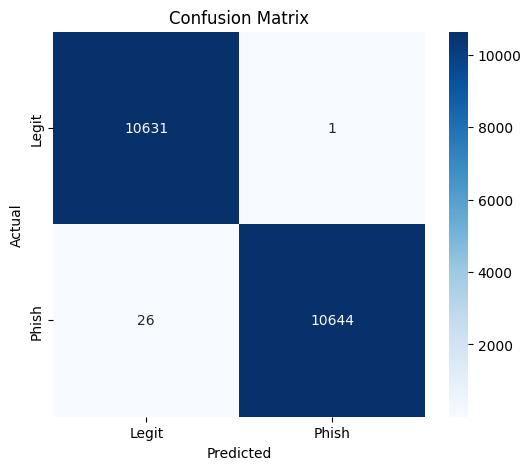


✔ Model saved as phishing_detector_v2.pkl

Test URL: http://secure-login.paypal.verify.com-account.info
Result: Phishing (100.0% risk)


In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import tldextract
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier

######################################################################
# 1. ENHANCED FEATURE EXTRACTION
######################################################################
def entropy(s):
    if not s: return 0
    counts = Counter(s)
    probs = [count / len(s) for count in counts.values()]
    return -sum(p * np.log2(p) for p in probs)

def extract_features(url):
    url = str(url).strip()
    parsed = urlparse(url)
    ext = tldextract.extract(url)

    domain = ext.domain
    sub = ext.subdomain
    path = parsed.path
    query = parsed.query
    
    # Check for brand spoofing
    brands = ["paypal", "google", "amazon", "microsoft", "netflix", "apple", "facebook", "bank"]
    brand_spoof = any(brand in url.lower() and brand != domain for brand in brands)

    return pd.Series({
        "url_length": len(url),
        "domain_length": len(domain),
        "path_length": len(path),
        "digits_in_url": sum(c.isdigit() for c in url),
        "special_chars": len(re.findall(r"[^A-Za-z0-9]", url)),
        "count_-": url.count("-"),
        "count_.": url.count("."),
        "count_/": url.count("/"),
        "count_?": url.count("?"),
        "count_=": url.count("="),
        "num_subdomains": len(sub.split(".")) if sub else 0,
        "has_https": int(parsed.scheme == "https"),
        "query_params": len(query.split("&")) if query else 0,
        "contains_ip": int(bool(re.match(r"^\d{1,3}(\.\d{1,3}){3}$", domain))),
        "is_punycode": int("xn--" in url),
        "brand_spoof": int(brand_spoof),
        "entropy": entropy(url),
        "has_login": int("login" in url.lower()),
        "has_secure": int("secure" in url.lower()),
        "has_update": int("update" in url.lower()),
        "has_verify": int("verify" in url.lower()),
    })

######################################################################
# 2. LOAD & PREPROCESS
######################################################################
print("Loading data...")
# Ensure train_url.csv exists in your directory
try:
    df = pd.read_csv("train_url.csv")
except FileNotFoundError:
    print("Error: 'train_url.csv' not found. Please ensure the file is in the correct directory.")
    exit()

# Rename 'content' to 'url' for consistency
if 'content' in df.columns:
    df = df.rename(columns={'content': 'url'})

# Map labels: 2 -> 0 (Legit), 3 -> 1 (Phishing)
df["label"] = df["label"].map({2: 0, 3: 1})

print("Extracting features (this may take a minute)...")
feature_df = df["url"].apply(extract_features)
df = pd.concat([df, feature_df], axis=1)

numeric_features = feature_df.columns.tolist()

X = df[["url"] + numeric_features]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

######################################################################
# 3. PIPELINE DEFINITION
######################################################################
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(2, 5), max_features=5000), "url")
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        tree_method='hist',
        random_state=42
    ))
])

######################################################################
# 4. TRAIN & EVALUATE
######################################################################
print("Training model...")
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print("\n--- Model Performance ---")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))

# Visualization: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Phish'], yticklabels=['Legit', 'Phish'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



# Save the model
with open("phishing_detector_v2.pkl", "wb") as f:
    pickle.dump(pipeline, f)
print("\n✔ Model saved as phishing_detector_v2.pkl")

# Save cleaned data
df.to_csv('data_processed.csv', index=False)

######################################################################
# 5. FIXED PREDICTION FUNCTION
######################################################################
def predict_url(input_url):
    # 1. Extract features
    feat_series = extract_features(input_url)
    
    # 2. Create DataFrame with identical structure as training X
    data = {"url": [input_url]}
    for col in numeric_features:
        data[col] = [feat_series[col]]
    
    df_pred = pd.DataFrame(data)
    
    # 3. Predict
    prob = pipeline.predict_proba(df_pred)[0][1]
    label = "Phishing" if prob > 0.5 else "Legitimate"
    
    return label, round(prob * 100, 2)

# Test run
test_url = "http://secure-login.paypal.verify.com-account.info"
lbl, risk = predict_url(test_url)
print(f"\nTest URL: {test_url}")
print(f"Result: {lbl} ({risk}% risk)")

In [2]:
import pandas as pd
import numpy as np
import re
import pickle
import tldextract
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from urllib.parse import urlparse
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

######################################################################
# 1. RE-USE FEATURE EXTRACTION (Must match training exactly)
######################################################################
def entropy(s):
    if not s: return 0
    counts = Counter(s)
    probs = [count / len(s) for count in counts.values()]
    return -sum(p * np.log2(p) for p in probs)

def extract_features(url):
    url = str(url).strip()
    parsed = urlparse(url)
    ext = tldextract.extract(url)
    domain, sub = ext.domain, ext.subdomain
    
    brands = ["paypal", "google", "amazon", "microsoft", "netflix", "apple", "facebook", "bank"]
    brand_spoof = any(brand in url.lower() and brand != domain for brand in brands)

    return pd.Series({
        "url_length": len(url),
        "domain_length": len(domain),
        "path_length": len(parsed.path),
        "digits_in_url": sum(c.isdigit() for c in url),
        "special_chars": len(re.findall(r"[^A-Za-z0-9]", url)),
        "count_-": url.count("-"),
        "count_.": url.count("."),
        "count_/": url.count("/"),
        "count_?": url.count("?"),
        "count_=": url.count("="),
        "num_subdomains": len(sub.split(".")) if sub else 0,
        "has_https": int(parsed.scheme == "https"),
        "query_params": len(parsed.query.split("&")) if parsed.query else 0,
        "contains_ip": int(bool(re.match(r"^\d{1,3}(\.\d{1,3}){3}$", domain))),
        "is_punycode": int("xn--" in url),
        "brand_spoof": int(brand_spoof),
        "entropy": entropy(url),
        "has_login": int("login" in url.lower()),
        "has_secure": int("secure" in url.lower()),
        "has_update": int("update" in url.lower()),
        "has_verify": int("verify" in url.lower()),
    })

######################################################################
# 2. LOAD MODEL AND TEST DATA
######################################################################
MODEL_PATH = "phishing_detector_v2.pkl"
TEST_DATA_PATH = "dataset_phishing.csv" # Change this to your test file

print(f"--- Loading Model: {MODEL_PATH} ---")
with open(MODEL_PATH, "rb") as f:
    pipeline = pickle.load(f)

print(f"--- Loading Test Data: {TEST_DATA_PATH} ---")
test_df = pd.read_csv(TEST_DATA_PATH)

# Standardize column names
if "URL" in test_df.columns:
    test_df = test_df.rename(columns={"URL": "url"})

# Handle Labels (Mapping your dataset's labels to 0 and 1)
# Example: 'legitimate' -> 0, 'phishing' -> 1
label_map = {"legitimate": 0, "phishing": 1, 2: 0, 3: 1}
test_df['target'] = test_df['status'].map(label_map)

# Drop rows with missing labels to prevent calculation errors
test_df = test_df.dropna(subset=['target'])
y_true = test_df['target'].astype(int)

######################################################################
# 3. PREDICTION
######################################################################
print("Extracting features and predicting...")
features = test_df["url"].apply(extract_features)
X_test = pd.concat([test_df[["url"]], features], axis=1)

y_pred = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)[:, 1]

######################################################################
# 4. EVALUATION
######################################################################
print("\n" + "="*40)
print("FINAL TEST RESULTS")
print("="*40)
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Legitimate", "Phishing"]))

# Confusion Matrix Visualization

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted Legit', 'Predicted Phish'],
            yticklabels=['Actual Legit', 'Actual Phish'])
plt.title('Phishing Detector Confusion Matrix')
plt.show()

# Save predictions to a file for review
test_df['prediction'] = y_pred
test_df['risk_score'] = (y_probs * 100).round(2)
test_df.to_csv("test_results_detailed.csv", index=False)
print("\n✔ Detailed results saved to 'test_results_detailed.csv'")

--- Loading Model: phishing_detector_v2.pkl ---
--- Loading Test Data: dataset_phishing.csv ---
Extracting features and predicting...


ValueError: columns are missing: {'count_=', 'entropy', 'has_https', 'has_update', 'query_params', 'has_verify', 'count_-', 'brand_spoof', 'count_?', 'count_.', 'domain_length', 'special_chars', 'is_punycode', 'count_/', 'digits_in_url', 'has_secure', 'path_length', 'has_login', 'num_subdomains', 'contains_ip', 'url_length'}

In [3]:
import pandas as pd
import numpy as np
import re
import pickle
import tldextract
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from urllib.parse import urlparse
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ----------------------------------------------------------------------
# 1. FEATURE EXTRACTION (Must be identical to Training)
# ----------------------------------------------------------------------
def entropy(s):
    if not s: return 0
    counts = Counter(s)
    probs = [count / len(s) for count in counts.values()]
    return -sum(p * np.log2(p) for p in probs)

def extract_features(url):
    url = str(url).strip()
    parsed = urlparse(url)
    ext = tldextract.extract(url)
    domain, sub = ext.domain, ext.subdomain
    
    brands = ["paypal", "google", "amazon", "microsoft", "netflix", "apple", "facebook", "bank"]
    brand_spoof = any(brand in url.lower() and brand != domain for brand in brands)

    return pd.Series({
        "url_length": len(url),
        "domain_length": len(domain),
        "path_length": len(parsed.path),
        "digits_in_url": sum(c.isdigit() for c in url),
        "special_chars": len(re.findall(r"[^A-Za-z0-9]", url)),
        "count_-": url.count("-"),
        "count_.": url.count("."),
        "count_/": url.count("/"),
        "count_?": url.count("?"),
        "count_=": url.count("="),
        "num_subdomains": len(sub.split(".")) if sub else 0,
        "has_https": int(parsed.scheme == "https"),
        "query_params": len(parsed.query.split("&")) if parsed.query else 0,
        "contains_ip": int(bool(re.match(r"^\d{1,3}(\.\d{1,3}){3}$", domain))),
        "is_punycode": int("xn--" in url),
        "brand_spoof": int(brand_spoof),
        "entropy": entropy(url),
        "has_login": int("login" in url.lower()),
        "has_secure": int("secure" in url.lower()),
        "has_update": int("update" in url.lower()),
        "has_verify": int("verify" in url.lower()),
    })

# ----------------------------------------------------------------------
# 2. LOAD MODEL AND PREPARE DATA
# ----------------------------------------------------------------------
try:
    with open("phishing_detector_v2.pkl", "rb") as f:
        pipeline = pickle.load(f)
    print("✔ Model loaded successfully.")
except FileNotFoundError:
    print("❌ Error: 'phishing_detector_v2.pkl' not found.")
    exit()

# Load the external test dataset
df_test = pd.read_csv("dataset_phishing.csv")

# Standardize URL column name
if "URL" in df_test.columns:
    df_test = df_test.rename(columns={"URL": "url"})

# Robust Label Mapping (Handles strings like 'phishing' or numbers like 2, 3)
label_map = {"legitimate": 0, "phishing": 1, 2: 0, 3: 1, "0": 0, "1": 1}
if "status" in df_test.columns:
    df_test["label_gold"] = df_test["status"].map(label_map)
    # Remove rows where label mapping failed
    df_test = df_test.dropna(subset=["label_gold"])
    y_true = df_test["label_gold"].astype(int)
else:
    print("❌ Error: 'status' column not found in dataset.")
    exit()

# ----------------------------------------------------------------------
# 3. FEATURE ALIGNMENT & PREDICTION
# ----------------------------------------------------------------------
print("Extracting features (processing URLs)...")
# Generate the numeric feature dataframe
feature_df = df_test["url"].apply(extract_features)

# CRITICAL STEP: Construct X_test to match training column names exactly
# It must contain the 'url' column AND all numeric columns from extract_features
X_test = pd.concat([df_test[["url"]], feature_df], axis=1)

print("Running model prediction...")
try:
    y_pred = pipeline.predict(X_test)
    y_probs = pipeline.predict_proba(X_test)[:, 1]
except ValueError as e:
    print("\n❌ COLUMN MISMATCH ERROR DETECTED!")
    print(f"Model expects: {pipeline.named_steps['preprocess'].feature_names_in_}")
    print(f"You provided: {X_test.columns.tolist()}")
    raise e

# ----------------------------------------------------------------------
# 4. PERFORMANCE ANALYSIS
# ----------------------------------------------------------------------
print("\n" + "="*40)
print("METRICS REPORT")
print("="*40)
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Legitimate", "Phishing"]))

# Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Predicted Legit', 'Predicted Phish'],
            yticklabels=['Actual Legit', 'Actual Phish'])
plt.title('Phishing Detection Confusion Matrix')
plt.show()

# Save detailed results
df_test["predicted_label"] = y_pred
df_test["risk_percentage"] = (y_probs * 100).round(2)
df_test.to_csv("test_results_detailed.csv", index=False)
print("\n✔ Detailed results saved to 'test_results_detailed.csv'")

✔ Model loaded successfully.
Extracting features (processing URLs)...
Running model prediction...

❌ COLUMN MISMATCH ERROR DETECTED!
Model expects: ['url' 'url_length' 'domain_length' 'path_length' 'digits_in_url'
 'special_chars' 'count_-' 'count_.' 'count_/' 'count_?' 'count_='
 'num_subdomains' 'has_https' 'query_params' 'contains_ip' 'is_punycode'
 'brand_spoof' 'entropy' 'has_login' 'has_secure' 'has_update'
 'has_verify']
You provided: ['url', 'url']


ValueError: columns are missing: {'count_=', 'entropy', 'has_https', 'has_update', 'query_params', 'has_verify', 'count_-', 'brand_spoof', 'count_?', 'count_.', 'domain_length', 'special_chars', 'is_punycode', 'count_/', 'digits_in_url', 'has_secure', 'path_length', 'has_login', 'num_subdomains', 'contains_ip', 'url_length'}